# nuScenes v1.0-trainval Parts 1–2

Merging nuScenes trainval file parts 1 and 2

In [7]:
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from nuscenes.nuscenes import NuScenes


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.data_loader.nuscenes_front_loader import load_scene_names
from src.utils import resolve_path

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 3)
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/williamkuo/Desktop/imec


## 1. Available data audit

First load the official metadata, then independently check which scenes have every required `CAM_FRONT` keyframe and up to five `RADAR_FRONT` sweeps. A scene is accepted only when every selected sample has the required files.

In [8]:
config = load_config()
dataset_config = config['dataset']
dataroot = resolve_path(config['train']['dataroot'])
camera_channel = config['camera_channel']
radar_channels = tuple(config['radar']['channels'])
nsweeps = int(config['radar']['nsweeps'])

nusc = NuScenes(
    version=dataset_config['version'],
    dataroot=str(dataroot),
    verbose=False,
)

train_scene_names = load_scene_names(
    resolve_path(dataset_config['scene_manifests']['train'])
)
val_scene_names = load_scene_names(
    resolve_path(dataset_config['scene_manifests']['val'])
)

print(f'Metadata scenes: {len(nusc.scene):,}')
print(f'Metadata keyframes: {len(nusc.sample):,}')
print(f'Metadata annotations: {len(nusc.sample_annotation):,}')
print(f'Dataroot: {dataroot}')

Metadata scenes: 850
Metadata keyframes: 34,149
Metadata annotations: 1,166,187
Dataroot: /Users/williamkuo/Desktop/imec/v1.0-trainval-parts1-2


In [9]:
scene_by_token = {scene['token']: scene for scene in nusc.scene}
samples_by_scene = defaultdict(list)
for sample in nusc.sample:
    samples_by_scene[sample['scene_token']].append(sample)


def required_sensor_files_exist(sample):
    camera_record = nusc.get('sample_data', sample['data'][camera_channel])
    if not (dataroot / camera_record['filename']).is_file():
        return False

    for radar_channel in radar_channels:
        radar_token = sample['data'][radar_channel]
        for _ in range(nsweeps): # check if it contains all sweeps
            radar_record = nusc.get('sample_data', radar_token)
            if not (dataroot / radar_record['filename']).is_file():
                return False
            if not radar_record['prev']:
                break
            radar_token = radar_record['prev']
    return True


available_scene_tokens = {
    scene_token
    for scene_token, samples in samples_by_scene.items()
    if all(required_sensor_files_exist(sample) for sample in samples)
}
available_scene_names = sorted(
    scene_by_token[token]['name'] for token in available_scene_tokens
)
available_samples = [
    sample for sample in nusc.sample
    if sample['scene_token'] in available_scene_tokens
]

print(f'Complete available scenes: {len(available_scene_names):,}')
print(f'Complete available keyframes: {len(available_samples):,}')

Complete available scenes: 170
Complete available keyframes: 6,743


In [10]:
physical_file_counts = {
    'CAM_FRONT keyframes': sum(path.is_file() for path in (dataroot / 'samples' / 'CAM_FRONT').glob('*')),
    'RADAR_FRONT keyframes': sum(path.is_file() for path in (dataroot / 'samples' / 'RADAR_FRONT').glob('*')),
    'RADAR_FRONT sweeps': sum(path.is_file() for path in (dataroot / 'sweeps' / 'RADAR_FRONT').glob('*')),
}

availability_summary = pd.DataFrame(
    [
        ('Physically available complete scenes', len(available_scene_names)),
        ('Physically available keyframes', len(available_samples)),
        *physical_file_counts.items(),
    ],
    columns=['Statistic', 'Count'],
).set_index('Statistic')
display(availability_summary.style.format('{:,.0f}'))

,Count
Statistic,
Physically available complete scenes,170
Physically available keyframes,"6,743"
CAM_FRONT keyframes,"6,743"
RADAR_FRONT keyframes,"6,743"
RADAR_FRONT sweeps,"37,224"


## 2. Scene-level distribution

In [11]:
# split train and val by scene
split_by_scene = {name: 'train' for name in train_scene_names}
split_by_scene.update({name: 'validation' for name in val_scene_names})
scene_rows = []

for scene_index, scene_token in enumerate(sorted(available_scene_tokens), start=1):
    scene = scene_by_token[scene_token]
    samples = sorted(samples_by_scene[scene_token], key=lambda item: item['timestamp'])
    visible_pedestrian_boxes = 0
    radar_supported_boxes = 0
    pedestrian_instances = set()

    for sample in samples:
        _, boxes, _ = nusc.get_sample_data(sample['data'][camera_channel])
        pedestrian_boxes = [box for box in boxes if config['class_name'] in box.name]
        visible_pedestrian_boxes += len(pedestrian_boxes)
        for box in pedestrian_boxes:
            annotation = nusc.get('sample_annotation', box.token)
            pedestrian_instances.add(annotation['instance_token'])
            radar_supported_boxes += annotation['num_radar_pts'] > 0

    log = nusc.get('log', scene['log_token'])
    scene_rows.append({
        'scene': scene['name'],
        'split': split_by_scene.get(scene['name'], 'unassigned'),
        'location': log['location'],
        'keyframes': len(samples),
        'front_pedestrian_boxes': visible_pedestrian_boxes,
        'unique_pedestrian_instances': len(pedestrian_instances),
        'radar_supported_boxes_all_sensors': radar_supported_boxes,
    })

    if scene_index % 25 == 0 or scene_index == len(available_scene_tokens):
        print(f'Processed scene {scene_index}/{len(available_scene_tokens)}', flush=True)

scene_frame = pd.DataFrame(scene_rows).sort_values('scene').reset_index(drop=True)
scene_frame.head()

Processed scene 25/170
Processed scene 50/170
Processed scene 75/170
Processed scene 100/170
Processed scene 125/170
Processed scene 150/170
Processed scene 170/170


,scene,split,location,keyframes,front_pedestrian_boxes,unique_pedestrian_instances,radar_supported_boxes_all_sensors
0,scene-0001,train,singapore-onenorth,40,57,4,3
1,scene-0002,train,singapore-onenorth,40,30,4,1
2,scene-0003,train,singapore-onenorth,40,136,6,14
3,scene-0004,train,singapore-onenorth,40,176,17,16
4,scene-0005,validation,singapore-onenorth,39,16,3,0


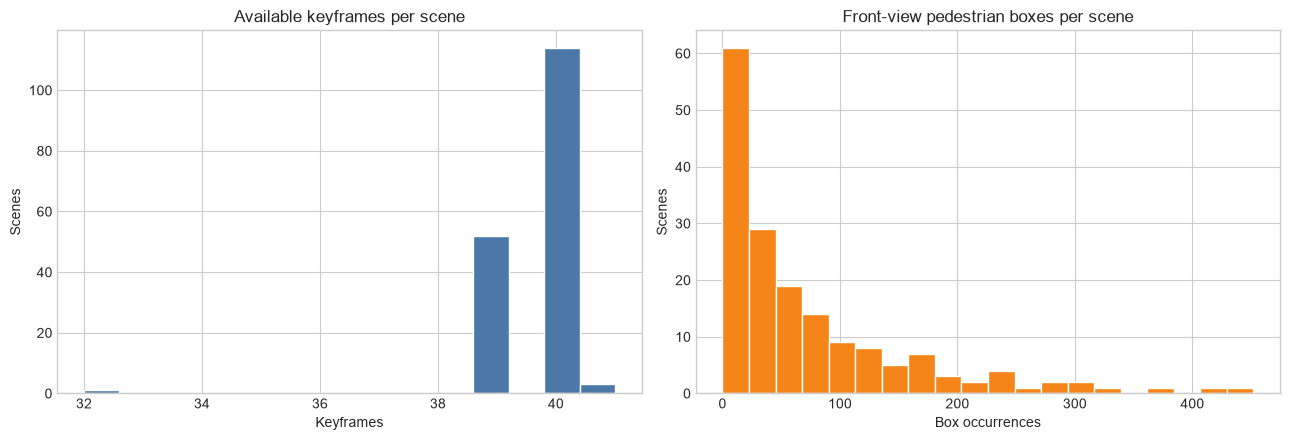

,count,mean,std,min,25%,50%,75%,max
keyframes,170.0,39.665,0.769,32.0,39.0,40.0,40.00,41.0
front_pedestrian_boxes,170.0,72.641,87.251,0.0,12.0,42.5,106.00,452.0
unique_pedestrian_instances,170.0,7.541,8.672,0.0,1.0,4.5,11.00,49.0
radar_supported_boxes_all_sensors,170.0,8.771,11.105,0.0,0.0,5.0,12.75,61.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(scene_frame['keyframes'], bins=15, color='#4c78a8', edgecolor='white')
axes[0].set(title='Available keyframes per scene', xlabel='Keyframes', ylabel='Scenes')

axes[1].hist(scene_frame['front_pedestrian_boxes'], bins=20, color='#f58518', edgecolor='white')
axes[1].set(title='Front-view pedestrian boxes per scene', xlabel='Box occurrences', ylabel='Scenes')
plt.tight_layout()
plt.show()

scene_distribution_summary = scene_frame[[
    'keyframes',
    'front_pedestrian_boxes',
    'unique_pedestrian_instances',
    'radar_supported_boxes_all_sensors',
]].describe().T
display(scene_distribution_summary)

## Scene duration
- Very balanced
- Almost all have ~40 keyframes

## Pedestrian distribution
- Highly imbalanced
- 0 ~ 452 boxes per scene

## Pedestrian diversity
- Fewer than box count
- Median is only 4.5 unique instances per scene

## Radar support
- Very sparse
- Only about 12% of annotation-level boxes have radar support

location,boston-seaport,singapore-onenorth,singapore-queenstown
split,,,
train,52,75,9
validation,13,19,2


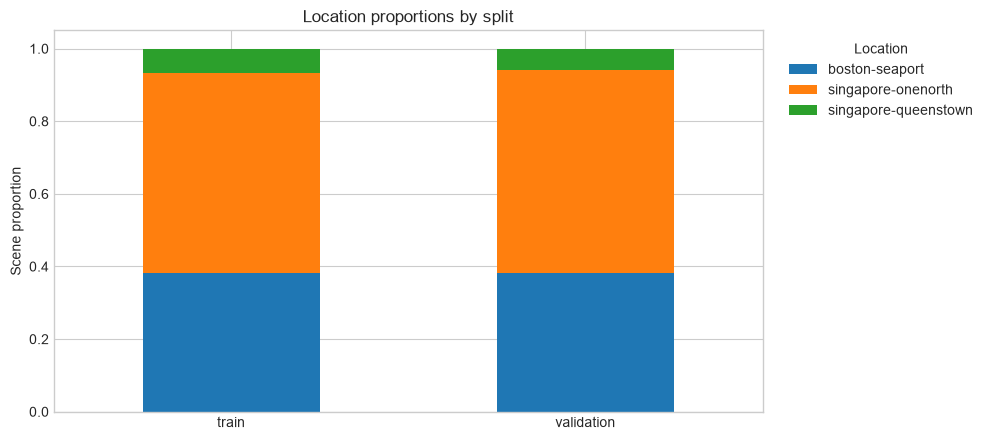

In [13]:
location_frame = pd.crosstab(scene_frame['split'], scene_frame['location'])
location_proportion = location_frame.div(location_frame.sum(axis=1), axis=0)
display(location_frame)

ax = location_proportion.plot(kind='bar', stacked=True, figsize=(10, 4.5), rot=0)
ax.set(title='Location proportions by split', xlabel='', ylabel='Scene proportion')
ax.legend(title='Location', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Train/validation split

### Design:

- The final split is fixed by tracked scene manifests
- The split guarantees completeness, exclusivity, effective frame counts, and scene-level distribution similarity.

In [14]:
train_set = set(train_scene_names)
val_set = set(val_scene_names)
available_set = set(available_scene_names)

assert len(train_scene_names) == len(train_set), 'Duplicate train scenes.'
assert len(val_scene_names) == len(val_set), 'Duplicate validation scenes.'
assert not train_set & val_set, 'Train/validation scene leakage.'
assert train_set | val_set == available_set, 'Manifests do not cover the available pool exactly.'
assert set(scene_frame['split']) == {'train', 'validation'}

print(f'Train scenes: {len(train_set)}')
print(f'Validation scenes: {len(val_set)}')
print(f'Scene overlap: {len(train_set & val_set)}')
print(f'Unassigned available scenes: {len(available_set - train_set - val_set)}')

Train scenes: 136
Validation scenes: 34
Scene overlap: 0
Unassigned available scenes: 0


Train and validation have similar distributions in location, pedestrian density, and annotation-level Radar support

In [15]:
train_stride = int(config['train']['frame_stride'])
scene_frame['effective_keyframes'] = np.where(
    scene_frame['split'].eq('train'),
    (scene_frame['keyframes'] + train_stride - 1) // train_stride,
    scene_frame['keyframes'],
)

split_summary = scene_frame.groupby('split').agg(
    scenes=('scene', 'size'),
    full_keyframes=('keyframes', 'sum'),
    effective_keyframes=('effective_keyframes', 'sum'),
    front_pedestrian_boxes=('front_pedestrian_boxes', 'sum'),
    scenes_with_pedestrians=('front_pedestrian_boxes', lambda values: int((values > 0).sum())),
    radar_supported_boxes_all_sensors=('radar_supported_boxes_all_sensors', 'sum'),
)
split_summary['boxes_per_full_keyframe'] = (
    split_summary['front_pedestrian_boxes'] / split_summary['full_keyframes']
)
split_summary['annotation_radar_support_rate'] = (
    split_summary['radar_supported_boxes_all_sensors']
    / split_summary['front_pedestrian_boxes'].clip(lower=1)
)
display(split_summary)

,scenes,full_keyframes,effective_keyframes,front_pedestrian_boxes,scenes_with_pedestrians,radar_supported_boxes_all_sensors,boxes_per_full_keyframe,annotation_radar_support_rate
split,,,,,,,,
train,136,5393,2717,9866,110,1181,1.829,0.120
validation,34,1350,1350,2483,30,310,1.839,0.125


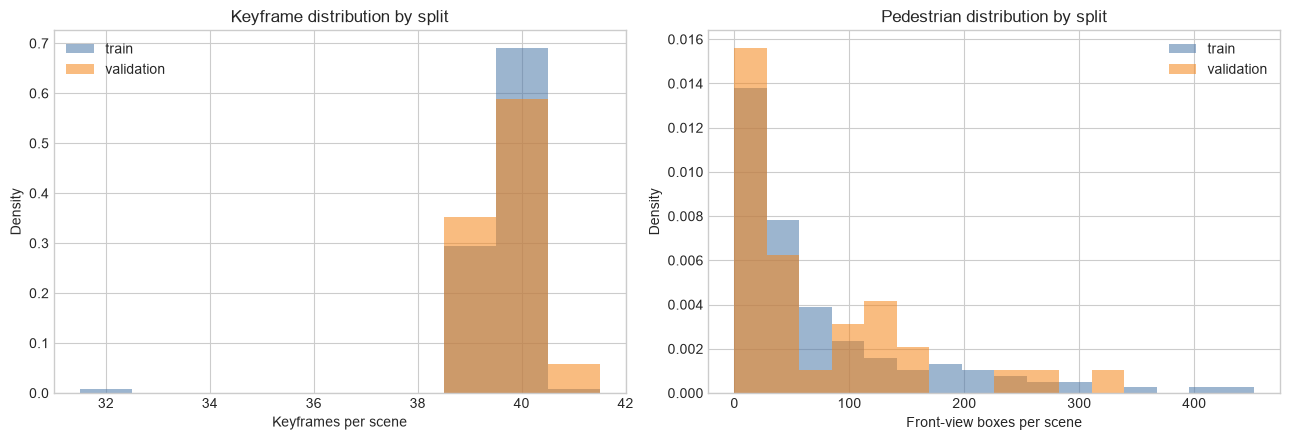

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Use the same bins for train and validation
keyframe_bins = np.arange(
    scene_frame['keyframes'].min() - 0.5,
    scene_frame['keyframes'].max() + 1.5,
    1,
)

pedestrian_bins = np.linspace(
    scene_frame['front_pedestrian_boxes'].min(),
    scene_frame['front_pedestrian_boxes'].max(),
    17,   # 16 bins
)

for split, color in [('train', '#4c78a8'), ('validation', '#f58518')]:
    subset = scene_frame[scene_frame['split'] == split]
    axes[0].hist(
        subset['keyframes'],
        bins=keyframe_bins,
        density=True,
        alpha=0.55,
        label=split,
        color=color,
    )
    axes[1].hist(
        subset['front_pedestrian_boxes'],
        bins=pedestrian_bins,
        density=True,
        alpha=0.55,
        label=split,
        color=color,
    )

axes[0].set(
    title='Keyframe distribution by split',
    xlabel='Keyframes per scene',
    ylabel='Density',
)

axes[1].set(
    title='Pedestrian distribution by split',
    xlabel='Front-view boxes per scene',
    ylabel='Density',
)

for axis in axes:
    axis.legend()

plt.tight_layout()
plt.show()